In [1]:
import numpy
import requests
import argparse
import sys
import os
import pandas as pd
import numpy as np
from urllib.parse import urlencode
import datamapplot

/Users/dmitriismirnov/opt/miniconda3/envs/datamapplot/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
shared_url = 'https://disk.yandex.ru/d/gC2HjizA3KQFIA'

In [3]:
final_url = base_url + urlencode(dict(public_key = shared_url))
response = requests.get(final_url)
download_url = response.json()['href']
download_response = requests.get(download_url)

In [4]:
filename = "DataMapPlot/SIRT6_abstracts_corpus.csv"
os.makedirs(os.path.dirname(filename), exist_ok=True)
with open(filename, 'wb') as f:
    f.write(download_response.content)

In [5]:
abstract_corpus = pd.read_csv(filename)

In [17]:
abstract_corpus

,titles,abstracts,year
0,Genomic Instability and Aging-like Phenotype i...,The Sir2 histone deacetylase functions as a ch...,2006-01-01
1,SIRT6 is a histone H3 lysine 9 deacetylase tha...,The Sir2 deacetylase regulates chromatin silen...,2008-01-01
2,SIRT6 Links Histone H3 Lysine 9 Deacetylation ...,Members of the sirtuin (SIRT) family of NAD-de...,2009-01-01
3,The sirtuin SIRT6 regulates lifespan in male mice,The significant increase in human lifespan dur...,2012-01-01
4,The Histone Deacetylase Sirt6 Regulates Glucos...,SIRT6 is a member of a highly conserved family...,2010-01-01
...,...,...,...
1643,Dynamic effects of sleep deprivation on emotio...,"Sleep, a core circadian rhythm, maintains phys...",2026-01-01
1644,Dynamic regulation of TBK1 lactylation shapes ...,The precise control of type I interferon (IFN-...,2026-01-01
1645,From ketogenic metabolism to targeted therapeu...,β-Hydroxybutyrylation (Kbhb) is a novel posttr...,2026-01-01
1646,Inflammation-targeted single-atom nanozymes dr...,Early brain injury (EBI) has been identified a...,2026-01-01


In [6]:
abstracts = abstract_corpus['abstracts']
titles = abstract_corpus['titles']
years = abstract_corpus['year']

In [7]:
title_abstracts = (
    abstract_corpus["titles"].fillna("") +
    ". " +
    abstract_corpus["abstracts"].fillna("")
).tolist()

In [8]:
reduced_embeddings = np.load("DataMapPlot/topics_embeddings.npy")

In [9]:
plot_df = pd.read_csv("DataMapPlot/bertopic_umap_embeddings.csv")
topic_info = pd.read_csv("./sirt6_paper_corpus/Data/Analysis_v2/Base_topic_info.csv")

In [10]:
topic_info[topic_info.Topic != -1].columns

Index(['Unnamed: 0', 'Topic', 'Count', 'Name', 'Representation', 'KeyBERT',
       'MMR', 'POS', 'Representative_Docs'],
      dtype='object')

In [11]:
topic_info.POS.values

array(["['wound healing', 'high glucose', 'oxidative stress', 'endothelial cells', 'insulin secretion', 'diabetic mice', 'coronary microvascular', 'blood flow', 'circadian rhythms', 'nuclear factor']",
       "['cancer cells', 'breast cancer', 'cell lines', 'lung cancer', 'cancer cell', 'tumor suppressor', 'prostate cancer', 'overall survival', 'cell death', 'tumor growth']",
       "['genome stability', 'molecular dynamics', 'histone deacetylase', 'acyl groups', 'strand break', 'genomic instability', 'strand breaks', 'lysine residues', 'chain fatty', 'life span']",
       "['liver disease', 'fatty liver', 'lipid metabolism', 'fat diet', 'lipid accumulation', 'hepatic steatosis', 'fatty acid', 'insulin resistance', 'adipose tissue', 'oxidative stress']",
       "['sleep deprivation', 'oxidative stress', 'peripheral nerve', 'neurodegenerative diseases', 'spinal cord', 'brain barrier', 'reperfusion injury', 'rat model', 'neuronal cells', 'neural stem']",
       "['osteogenic differentiat

In [12]:
short_labels = ["Outliers", 
                "Cancer Cell Biology",
                "Genome Stability and Aging",
                "Fatty Liver Metabolism",
                "Neurodegeneration and Oxidative Stress",
                "Stem Cells and Osteogenesis",
                "Lung and Kidney Injury",
                "Endothelial Dysfunction and Calcification",
                "Cardiac Hypertrophy and Failure",
                "Hepatocellular Carcinoma",
                "Oocyte Development and Aging",
                "Lung Fibrosis and Senescence",
                "Skeletal Muscle Atrophy"]  

In [13]:
plot_df = plot_df.merge(pd.DataFrame({"topic": range(-1,len(short_labels)-1), "short_label": short_labels}), on="topic")

In [16]:
plot_df.short_label.value_counts()

short_label
Cancer Cell Biology                          324
Outliers                                     276
Genome Stability and Aging                   268
Fatty Liver Metabolism                       149
Neurodegeneration and Oxidative Stress       125
Stem Cells and Osteogenesis                   93
Lung and Kidney Injury                        79
Endothelial Dysfunction and Calcification     55
Cardiac Hypertrophy and Failure               53
Hepatocellular Carcinoma                      52
Oocyte Development and Aging                  43
Lung Fibrosis and Senescence                  39
Skeletal Muscle Atrophy                       32
Name: count, dtype: int64

Using BERTopic I obtained a number of topics that described by the following keywords: 

<KEYWORDS>

Based on the information above, extract a short but highly descriptive topic label of at most 5 words. Make sure it is in the following format: 
topic: "<topic label>"

In [157]:
plot_df.head()

,x,y,topic,topic_label,short_label
0,1.967142,1.875157,1,1_dna_longevity_lifespan_chromatin,Genome Stability and Aging
1,2.457611,1.606226,1,1_dna_longevity_lifespan_chromatin,Genome Stability and Aging
2,2.619269,1.776188,1,1_dna_longevity_lifespan_chromatin,Genome Stability and Aging
3,2.071403,2.836995,1,1_dna_longevity_lifespan_chromatin,Genome Stability and Aging
4,2.505932,3.926403,2,2_liver_hepatic_lipid_fatty,Fatty Liver Metabolism


In [158]:
outlier_label = plot_df[plot_df.topic == -1].short_label.values.unique()

In [159]:
processed_labels = [str(label) if label != outlier_label[0] else "Outlier" for label in plot_df['short_label'].values]

In [160]:
processed_labels

['Genome Stability and Aging',
 'Genome Stability and Aging',
 'Genome Stability and Aging',
 'Genome Stability and Aging',
 'Fatty Liver Metabolism',
 'Genome Stability and Aging',
 'Genome Stability and Aging',
 'Cancer Cell Biology',
 'Genome Stability and Aging',
 'Genome Stability and Aging',
 'Fatty Liver Metabolism',
 'Lung and Kidney Injury',
 'Genome Stability and Aging',
 'Genome Stability and Aging',
 'Genome Stability and Aging',
 'Genome Stability and Aging',
 'Oocyte Development and Aging',
 'Cardiac Hypertrophy and Failure',
 'Skeletal Muscle Atrophy',
 'Fatty Liver Metabolism',
 'Genome Stability and Aging',
 'Cancer Cell Biology',
 'Genome Stability and Aging',
 'Outlier',
 'Fatty Liver Metabolism',
 'Outlier',
 'Hepatocellular Carcinoma',
 'Genome Stability and Aging',
 'Fatty Liver Metabolism',
 'Lung and Kidney Injury',
 'Stem Cells and Osteogenesis',
 'Genome Stability and Aging',
 'Lung and Kidney Injury',
 'Fatty Liver Metabolism',
 'Cancer Cell Biology',
 'Outli

In [161]:
embeddings_2d = plot_df[["x","y"]].values
topics = plot_df["short_label"].values

100%|██████████| 500/500 [00:00<00:00, 1319.34it/s]


Resetting positions to accord with alignment


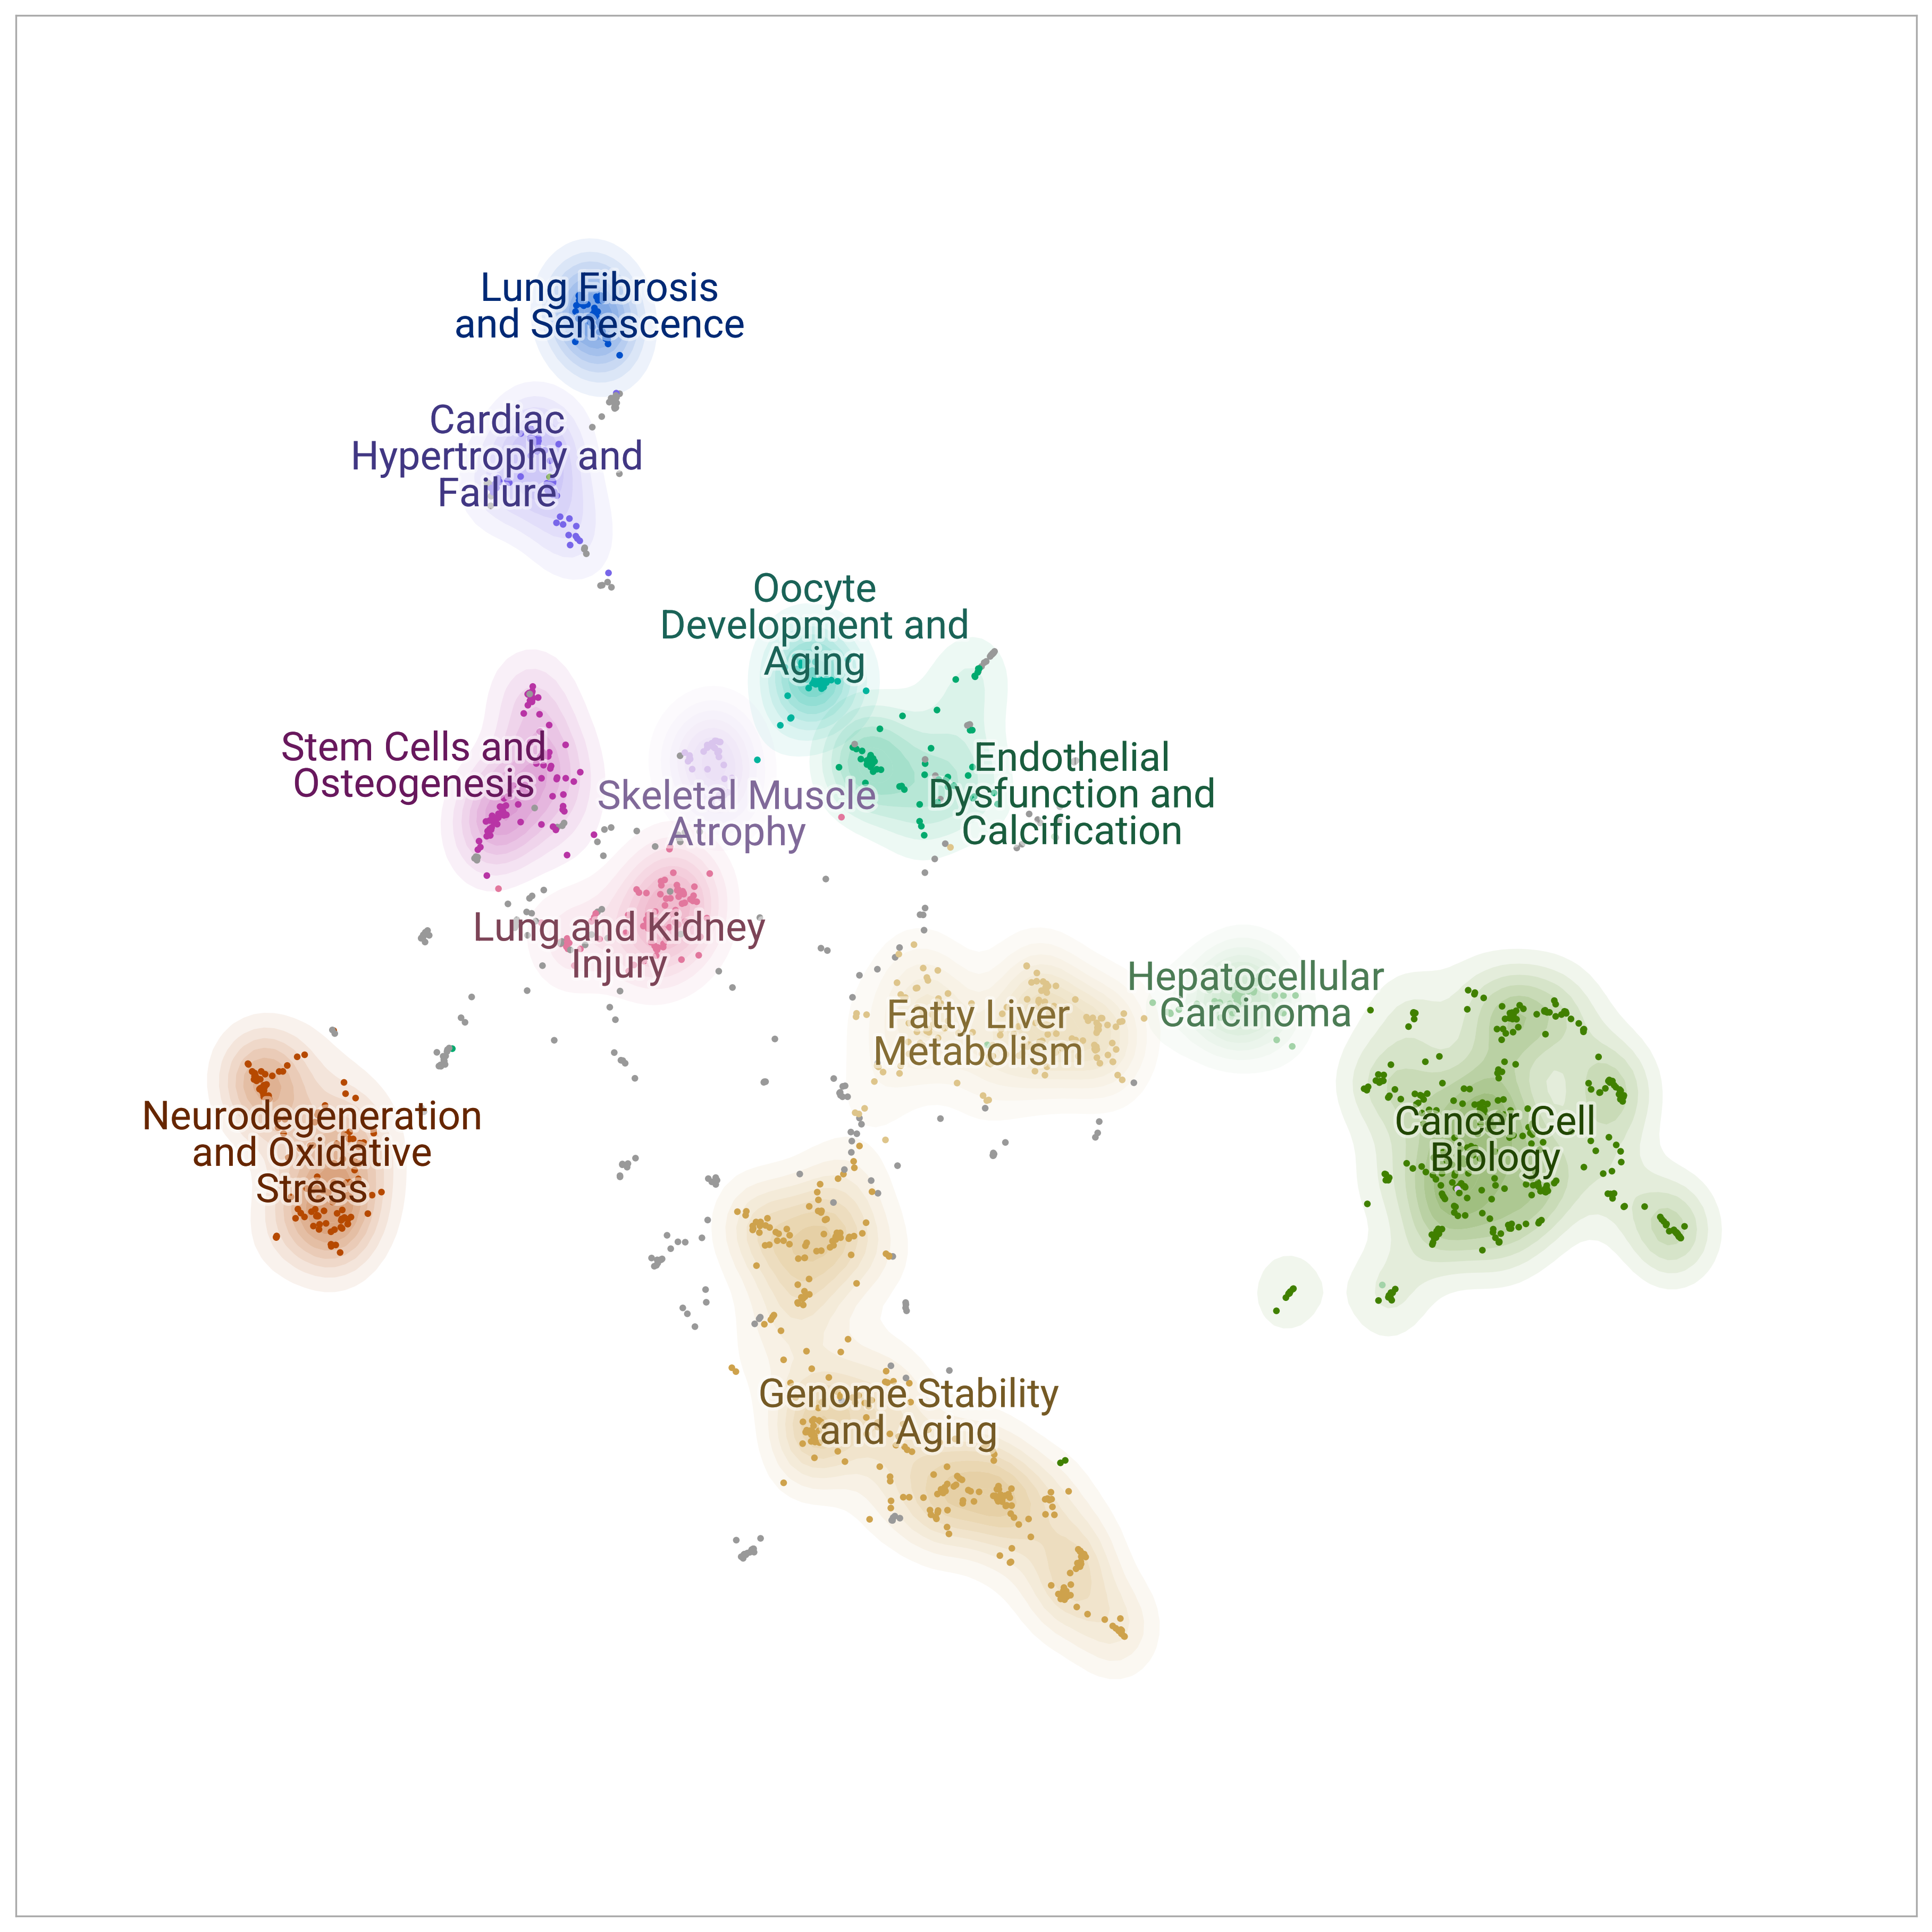

In [164]:
datamapplot.create_plot(
    embeddings_2d,
    labels=np.array(processed_labels), 
    label_font_size=18,
    label_over_points=True,
    noise_label = "Outlier",
    #noise_color = transparent_grey,
    #dynamic_label_size=True,
    highlight_label_keywords={
        "fontsize": 12, 
        "fontweight": "bold",
        "bbox":{"boxstyle":"circle",
                "pad":0.75
                }
    },
    dpi = 300
)

plt.savefig(
    "DataMapPlot/sirt6_topics_umap.png",
    dpi=300,
    bbox_inches="tight"
)